In [71]:
import pandas as pd
import numpy as np
from wordcloud import WordCloud
from collections import Counter
import re
from sklearn.feature_extraction.text import CountVectorizer
from nltk.util import ngrams
from nltk.corpus import stopwords
import nltk
import string
from nltk.tokenize import word_tokenize

In [72]:
df = pd.read_csv( r"E:\DATA sCIENCE\Data set\amazonreviews.tsv",
                sep = "\t",
                names = ['label','review'],
                quoting = 3)  # use for the quote issue
df

,label,review
0,label,review
1,pos,Stuning even for the non-gamer: This sound tra...
2,pos,The best soundtrack ever to anything.: I'm rea...
3,pos,"""Amazing!: This soundtrack is my favorite musi..."
4,pos,Excellent Soundtrack: I truly like this soundt...
...,...,...
9996,pos,"""A revelation of life in small town America in..."
9997,pos,Great biography of a very interesting journali...
9998,neg,Interesting Subject; Poor Presentation: You'd ...
9999,neg,Don't buy: The box looked used and it is obvio...


Task:

Data Cleaning: Remove duplicates, handle missing reviews if any, preprocess text (lowercasing, stopwords removal).

In [73]:
df = df.drop_duplicates(subset='review')
df

,label,review
0,label,review
1,pos,Stuning even for the non-gamer: This sound tra...
2,pos,The best soundtrack ever to anything.: I'm rea...
3,pos,"""Amazing!: This soundtrack is my favorite musi..."
4,pos,Excellent Soundtrack: I truly like this soundt...
...,...,...
9996,pos,"""A revelation of life in small town America in..."
9997,pos,Great biography of a very interesting journali...
9998,neg,Interesting Subject; Poor Presentation: You'd ...
9999,neg,Don't buy: The box looked used and it is obvio...


In [74]:
df = df.dropna(subset = ['review'])
df = df[df['review'].str.strip() != ""]
df

,label,review
0,label,review
1,pos,Stuning even for the non-gamer: This sound tra...
2,pos,The best soundtrack ever to anything.: I'm rea...
3,pos,"""Amazing!: This soundtrack is my favorite musi..."
4,pos,Excellent Soundtrack: I truly like this soundt...
...,...,...
9996,pos,"""A revelation of life in small town America in..."
9997,pos,Great biography of a very interesting journali...
9998,neg,Interesting Subject; Poor Presentation: You'd ...
9999,neg,Don't buy: The box looked used and it is obvio...


In [75]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [76]:
#Text Preprocessing
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text) # remove punctuation and numbers
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE) # for URl
    text = re.sub(r'\@\w+|', '', text) # Mentions and hashtags
    text = re.sub(r'[^\w\s]', '', text) # special characters and emojis
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

In [77]:
df['clean_review'] = df['review'].astype(str).apply(clean_text)


In [78]:
df.head()
df.info()
df.sample(5)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10001 entries, 0 to 10000
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   label         10001 non-null  object
 1   review        10001 non-null  object
 2   clean_review  10001 non-null  object
dtypes: object(3)
memory usage: 234.5+ KB


,label,review,clean_review
7085,neg,"""0 STARS: Total GARBAGE!!: This is one sorry, ...",stars total garbage one sorry cheap lowbudget ...
4578,pos,Beautiful Hair: This makes dull hair look fres...,beautiful hair makes dull hair look fresh much...
7452,neg,DOA: This item arrived as advertised. We plugg...,doa item arrived advertised plugged charger ca...
7402,neg,Painful to listen to: Fahrenheit 451 is a grea...,painful listen fahrenheit great book read dead...
6682,pos,helps children feel less afraid: My daughter w...,helps children feel less afraid daughter huge ...


Exploratory Analysis: Word clouds, sentiment distribution, most common positive/negative words.

In [81]:
df['label'].value_counts()

label
neg      5097
pos      4903
label       1
Name: count, dtype: int64

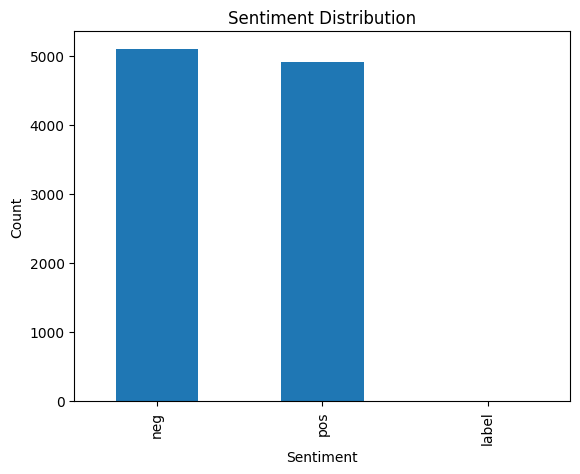

In [80]:
# sentiment distribution 
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [ ]:
#word clouds


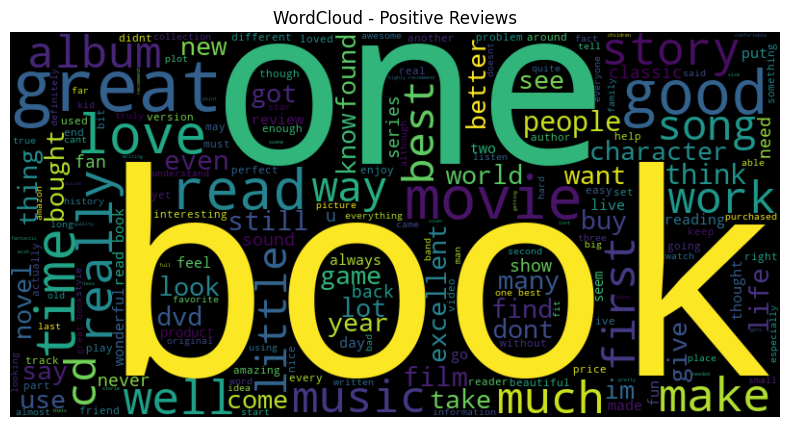

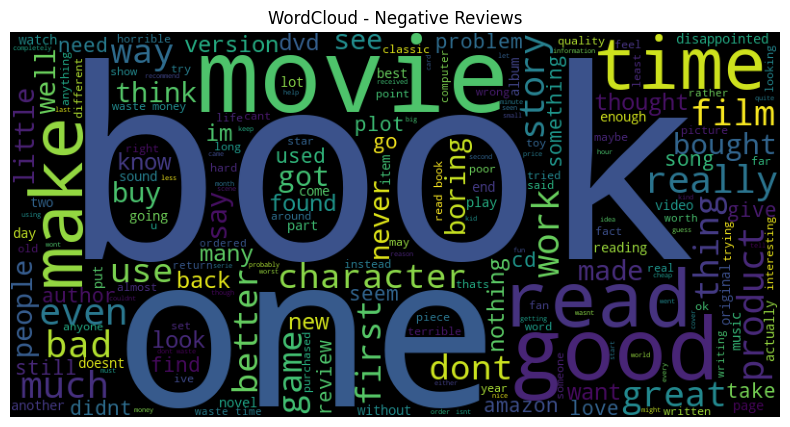

In [85]:
# Positive
positive_text = " ".join(df[df['label'] == 'pos']['clean_review'])

wordcloud_pos = WordCloud(width=800, height=400).generate(positive_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_pos ,  interpolation='bilinear')
plt.axis("off")
plt.title("WordCloud - Positive Reviews")
plt.show()

# Negative
negative_text = " ".join(df[df['label'] == 'neg']['clean_review'])

wordcloud_neg = WordCloud(width=800, height=400).generate(negative_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_neg)
plt.axis("off")
plt.title("WordCloud - Negative Reviews")
plt.show()


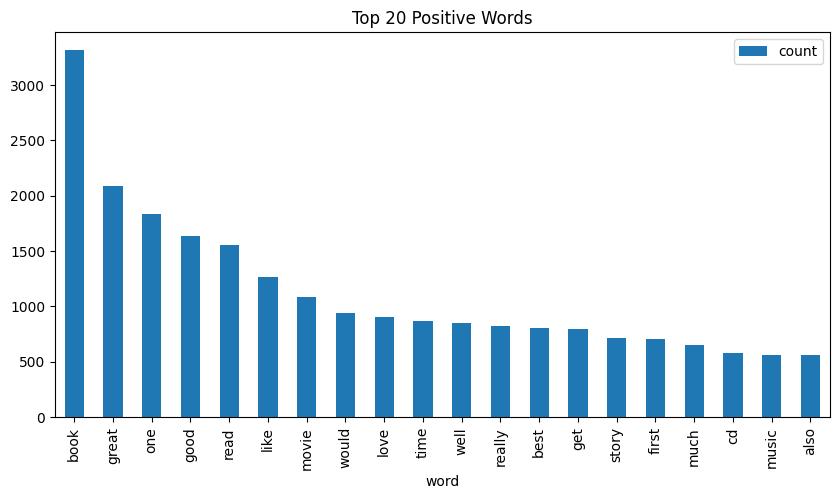

In [91]:
#most common positive/negative words
import seaborn as sns
pos_words = " ".join(df[df['label'] == 'pos']['clean_review']).split()
pos_common = Counter(pos_words).most_common(20)

pos_df = pd.DataFrame(pos_common, columns=['word','count'])
pos_df.plot(kind='bar', x='word', y='count', figsize=(10,5))
plt.title("Top 20 Positive Words")
plt.show()

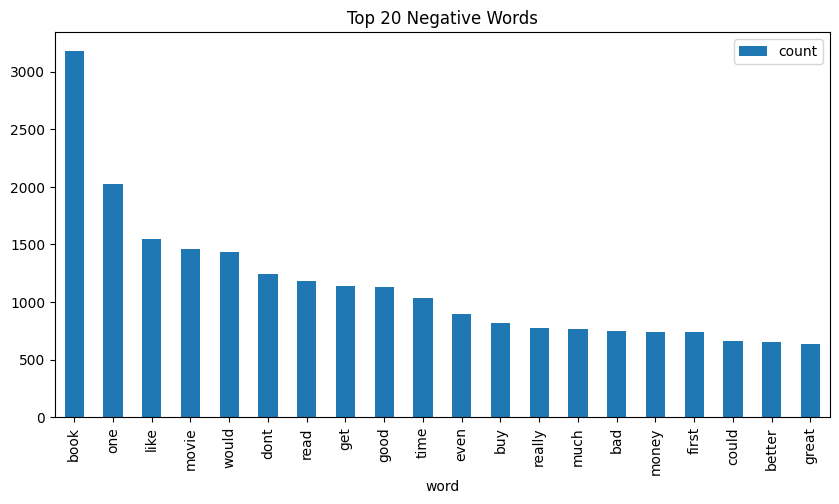

In [92]:
neg_words = " ".join(df[df['label']=='neg']['clean_review']).split()
neg_common = Counter(neg_words).most_common(20)

neg_df = pd.DataFrame(neg_common, columns=['word', 'count'])

neg_df.plot(kind='bar', x='word', y='count', figsize=(10,5))
plt.title("Top 20 Negative Words")
plt.show()


Model Development: Use NLP techniques (TF-IDF, Word2Vec, or BERT embeddings) with models like Logistic Regression, SVM, or Neural Networks.

In [95]:
# split the dataset

from sklearn.model_selection import train_test_split
X = df['clean_review']
y = df['label']
X_train,X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [98]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [104]:
# Build the model of logistic regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train_tfidf,y_train)

y_pred_lr = lr.predict(X_test_tfidf)

In [101]:
# Build the model of svm
from sklearn.svm import LinearSVC

svm_model = LinearSVC()
svm_model.fit(X_train_tfidf,y_train)
              
y_pred_svm = svm_model.predict(X_test_tfidf)


In [103]:
# Build the model for Neural network
from sklearn.neural_network import MLPClassifier

nn = MLPClassifier(hidden_layer_sizes = (128,64), max_iter=10)
nn.fit(X_train_tfidf, y_train)

y_pred_nn = nn.predict(X_test_tfidf)

C:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


Validation: Use train/test split, cross-validation, and metrics like accuracy, F1-score.

In [115]:
# cross-validation for lr model
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(lr, X_train_tfidf, y_train, cv=5)
print("5-Fold CV F1 Scores:", cv_scores)
print("Mean F1-Score:", np.mean(cv_scores))

5-Fold CV F1 Scores: [0.830625 0.86875  0.8525   0.83     0.856875]
Mean F1-Score: 0.8477499999999999


In [116]:
# cross-validation for svm model

cv_scores = cross_val_score(svm_model, X_train_tfidf, y_train, cv=5)
print("5-Fold CV F1 Scores:", cv_scores)
print("Mean F1-Score:", np.mean(cv_scores))

5-Fold CV F1 Scores: [0.83     0.84     0.83625  0.824375 0.84375 ]
Mean F1-Score: 0.8348749999999999


In [120]:
# cross-validation for MLPClassifier model

cv_scores = cross_val_score(nn, X_train_tfidf, y_train, cv=5)
print("5-Fold CV F1 Scores:", cv_scores)
#print("Mean F1-Score:", np.mean(cv_scores))

C:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the opti

5-Fold CV F1 Scores: [0.81875  0.838125 0.8175   0.79875  0.815625]


C:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


In [122]:
from sklearn.metrics import accuracy_score,classification_report, confusion_matrix

acc = accuracy_score(y_test, y_pred_lr)
print("Accuracy of Logistic Regression model:", acc)

acc = accuracy_score(y_test, y_pred_svm)
print("Accuracy of Logistic svm model:", acc)

acc = accuracy_score(y_test, y_pred_nn)
print("Accuracy of Logistic Neural network:", acc)


Accuracy of Logistic Regression model: 0.8515742128935532
Accuracy of Logistic svm model: 0.8380809595202399
Accuracy of Logistic Neural network: 0.8170914542728636


In [124]:
print("classification_report of lr_model :\n",classification_report(y_test, y_pred_lr))

classification_report of lr_model :
               precision    recall  f1-score   support

       label       0.00      0.00      0.00         1
         neg       0.85      0.86      0.85      1013
         pos       0.86      0.84      0.85       987

    accuracy                           0.85      2001
   macro avg       0.57      0.57      0.57      2001
weighted avg       0.85      0.85      0.85      2001



C:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average,

In [125]:
print("classification_report of svm_model :\n",classification_report(y_test, y_pred_svm))

classification_report of svm_model :
               precision    recall  f1-score   support

       label       0.00      0.00      0.00         1
         neg       0.83      0.86      0.84      1013
         pos       0.85      0.82      0.83       987

    accuracy                           0.84      2001
   macro avg       0.56      0.56      0.56      2001
weighted avg       0.84      0.84      0.84      2001



C:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average,

In [126]:
print("classification_report of lr_model :\n",classification_report(y_test, y_pred_nn))

classification_report of lr_model :
               precision    recall  f1-score   support

       label       0.00      0.00      0.00         1
         neg       0.80      0.85      0.82      1013
         pos       0.83      0.79      0.81       987

    accuracy                           0.82      2001
   macro avg       0.55      0.54      0.54      2001
weighted avg       0.82      0.82      0.82      2001



C:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average,